# PTC Example from Janesick: Ex 5.2

In [1]:
# Define the data

import pandas as pd
from io import StringIO

data = """
RAW_SIGNAL,Offset,S,Total_Noise,delta_noise,shot_noise,fpn
1.03E+02,1.02E+02,1.00E+00,4.95E+00,5.08E+00,8.73E-01,2.00E-02
1.04E+02,1.02E+02,1.62E+00,5.26E+00,5.18E+00,1.35E+00,3.20E-02
1.05E+02,1.02E+02,2.63E+00,4.93E+00,4.95E+00,7.16E-01,5.30E-02
1.06E+02,1.02E+02,4.27E+00,5.24E+00,5.20E+00,1.41E+00,8.50E-02
1.09E+02,1.02E+02,6.92E+00,5.36E+00,5.17E+00,1.30E+00,1.38E-01
1.13E+02,1.02E+02,1.12E+01,5.56E+00,5.33E+00,1.86E+00,2.24E-01
1.20E+02,1.02E+02,1.82E+01,6.33E+00,6.15E+00,3.58E+00,3.64E-01
1.32E+02,1.02E+02,2.95E+01,6.39E+00,6.51E+00,4.17E+00,5.90E-01
1.50E+02,1.02E+02,4.79E+01,7.87E+00,7.93E+00,6.16E+00,9.57E-01
1.80E+02,1.02E+02,7.76E+01,9.19E+00,8.96E+00,7.44E+00,1.55E+00
2.28E+02,1.02E+02,1.26E+02,1.08E+01,1.05E+01,9.22E+00,2.52E+00
3.06E+02,1.02E+02,2.04E+02,1.36E+01,1.27E+01,1.16E+01,4.08E+00
4.33E+02,1.02E+02,3.31E+02,1.76E+01,1.57E+01,1.49E+01,6.62E+00
6.39E+02,1.02E+02,5.37E+02,2.23E+01,1.95E+01,1.89E+01,1.07E+01
9.73E+02,1.02E+02,8.71E+02,2.98E+01,2.46E+01,2.41E+01,1.74E+01
1.51E+03,1.02E+02,1.41E+03,4.27E+01,3.06E+01,3.02E+01,2.83E+01
2.39E+03,1.02E+02,2.29E+03,5.92E+01,3.83E+01,3.80E+01,4.58E+01
3.82E+03,1.02E+02,3.72E+03,9.16E+01,5.13E+01,5.11E+01,7.43E+01
6.13E+03,1.02E+02,6.03E+03,1.39E+02,6.41E+01,6.39E+01,1.20E+02
9.87E+03,1.02E+02,9.77E+03,2.15E+02,7.75E+01,7.73E+01,1.95E+02
1.60E+04,1.02E+02,1.58E+04,3.28E+02,1.02E+02,1.02E+02,3.13E+02
2.58E+04,1.02E+02,2.57E+04,5.06E+02,1.18E+02,1.18E+02,4.87E+02
4.18E+04,1.02E+02,4.17E+04,6.79E+02,1.33E+02,1.33E+02,6.63E+02
6.77E+04,1.02E+02,6.76E+04,5.24E+02,8.35E+01,8.33E+01,5.09E+02
1.10E+05,1.02E+02,1.10E+05,3.51E+01,4.20E+00,2.71E+00,3.39E+01
"""

df = pd.read_csv(StringIO(data))



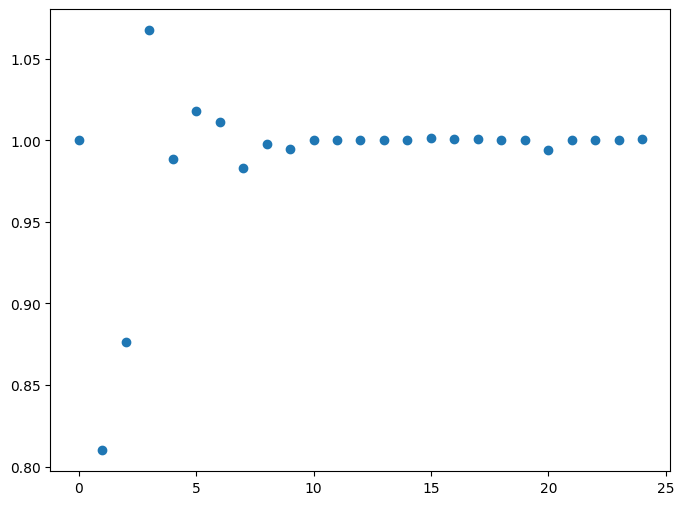

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Plot Signal Calc vs Signal from DataFrame
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(df["S"]/(df["RAW_SIGNAL"] - df["Offset"]), 'o')

# seems like there is some rounding errors in the table, since for small numbers the Signal derived
# from (RAW_SIGNAL - Offset) does not exactly match the S column, so we'll just use the S column directly

Read Noise: 4.95 DN
Calculated Gain: 1.56 e-/DN
Estimated Full Well: 41698.00 DN
Estimated Dynamic Range: 8423.84 
Estimated Dynamic Range: 78.51 dB 


/Users/nlourie/Desktop/Work/MIT/Optical Testing/GIT/optical-testing-analysis-tools/.conda/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


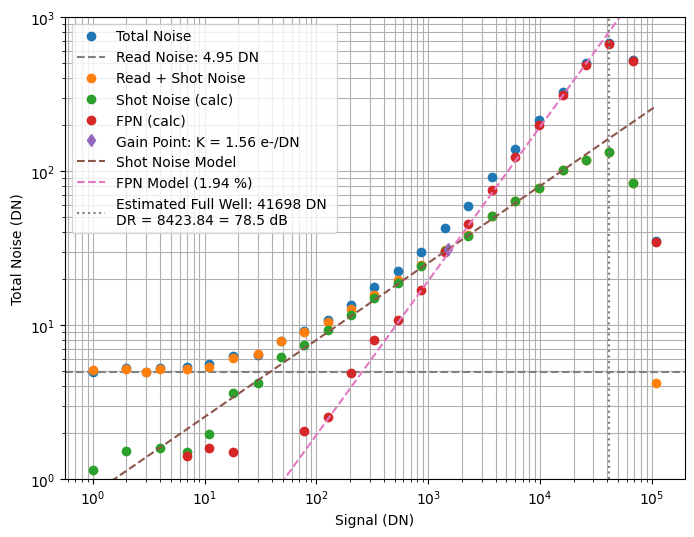

In [3]:
fig, ax = plt.subplots(figsize=(8,6))
#ax.plot(df["S"], df["Total_Noise"], 'o', label = "Total Noise")
#signal = df["S"]
signal = df["RAW_SIGNAL"] - df["Offset"]
ax.plot(signal, df["Total_Noise"], 'o', label = "Total Noise")

ax.set_xlabel("Signal (DN)")
ax.set_ylabel("Total Noise (DN)")
ax.set_yscale("log")
ax.set_xscale("log")
ax.grid(True, which="both", ls="-")
ax.set_ylim(1, 1e3)

# Get the read noise
read_noise = np.mean(df["Total_Noise"].iloc[0])
print(f"Read Noise: {read_noise} DN")
ax.axhline(read_noise, color='gray', ls='--', label = f"Read Noise: {read_noise:.2f} DN")

# Use the FPN removed delta noise
read_plus_shot_noise = df["delta_noise"]
ax.plot(signal, read_plus_shot_noise, 'o', label = "Read + Shot Noise")
shot_noise = np.sqrt(read_plus_shot_noise**2 - read_noise**2)
ax.plot(signal, shot_noise, 'o', label = "Shot Noise (calc)")
#ax.plot(signal, df["shot_noise"], 'o', label = "Shot Noise (table)")

# Calculate the FPN
fpn = np.sqrt(df["Total_Noise"]**2 - read_plus_shot_noise**2)
ax.plot(signal, fpn, 'o', label = "FPN (calc)")

# Fit the shot noise in specified signal region
#shot_noise_fit_region = (shot_noise > 10) & (shot_noise < 50)
#shot_noise_fit = np.polyfit(np.log10(signal[shot_noise_fit_region]), 
#                            np.log10(shot_noise[shot_noise_fit_region]), 1)
#print(f"Shot Noise Fit: slope = {shot_noise_fit[0]}, intercept = {shot_noise_fit[1]}")
#shot_noise_fit_line = 10**(shot_noise_fit[1]) * signal**(shot_noise_fit[0])
#ax.plot(signal, shot_noise_fit_line, '--', label = "Shot Noise Fit")

# Pick a point to calculate gain
signal_point = 1.5e3
shot_noise_point = np.interp(signal_point, signal, shot_noise)
gain = signal_point / (shot_noise_point**2)
print(f"Calculated Gain: {gain:.2f} e-/DN")
ax.plot(signal_point, shot_noise_point, 'd', label = f"Gain Point: K = {gain:.2f} e-/DN")

# plot gain line
shot_noise_gain_line = np.sqrt(signal / gain)
ax.plot(signal, shot_noise_gain_line, '--', label = "Shot Noise Model")

# pick a point to calculate FPN %
signal_val_for_fpn_cal = 20000
fpn_value = np.interp(signal_val_for_fpn_cal, signal, fpn)
fpn_percent = (fpn_value / signal_val_for_fpn_cal) * 100
fpn_line = (fpn_percent / 100) * signal
ax.plot(signal, fpn_line, '--', label = f"FPN Model ({fpn_percent:.2f} %)")

# get the full well: signal where total noise is maximum
fw = signal[np.argmax(df["Total_Noise"])]
print(f"Estimated Full Well: {fw:.2f} DN")    
dynamic_range = fw / read_noise
print(f"Estimated Dynamic Range: {dynamic_range:.2f} ")

dynamic_range_db = 20 * np.log10(dynamic_range)
print(f"Estimated Dynamic Range: {dynamic_range_db:.2f} dB ")

ax.axvline(fw, color='gray', ls=':', 
           label = f"Estimated Full Well: {fw:.0f} DN \nDR = {dynamic_range:.2f} = {dynamic_range_db:.1f} dB")



ax.legend()


PTC Fit for read_plus_shot_noise: slope = 0.6460151509830844, intercept = 33.746060355759454
 Read Noise from PTC Fit: 5.81 DN
Calculated Gain from Variance PTC for read_plus_shot_noise: 1.55 e-/DN
PTC Fit for shot_noise: slope = 0.6455949752666253, intercept = 13.379914563866123
Calculated Gain from Variance PTC for shot_noise: 1.55 e-/DN


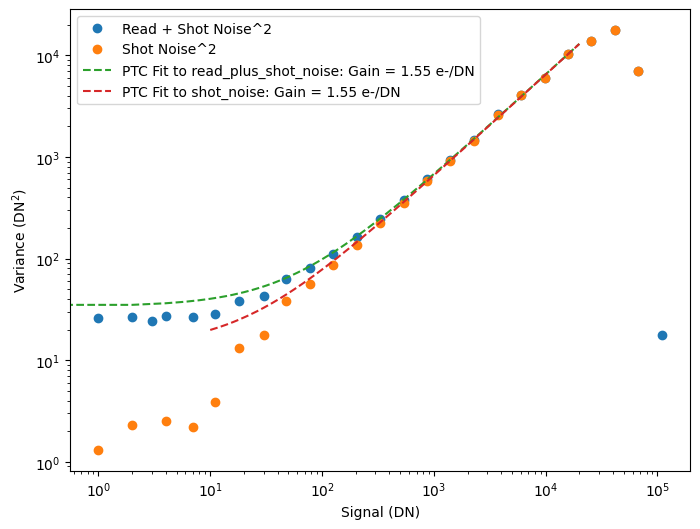

In [30]:
# what if we did a variance PTC instead?

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(signal, read_plus_shot_noise**2, 'o', label = "Read + Shot Noise^2")
ax.plot(signal, shot_noise**2, 'o', label = "Shot Noise^2")
ax.set_xlabel("Signal (DN)")
ax.set_ylabel("Variance (DN$^2$)")


var_methods = dict({
    "read_plus_shot_noise": {"label" : "Read Plus Shot Noise", "data": read_plus_shot_noise**2, "fit_signal_min": 0, "fit_signal_max": 2e4},
    "shot_noise": {"label": "Shot Noise", "data": shot_noise**2, "fit_signal_min": 10, "fit_signal_max": 2e4},
        })
for label, var_info in var_methods.items():
    fit_signal_min = var_info["fit_signal_min"]
    fit_signal_max = var_info["fit_signal_max"]
    fit_range = (signal > fit_signal_min) & (signal < fit_signal_max)
    ptc_fit = np.polyfit(signal[fit_range], var_info["data"][fit_range], 1)
    print(f"PTC Fit for {label}: slope = {ptc_fit[0]}, intercept = {ptc_fit[1]}")
    if label == "read_plus_shot_noise":
        print(f" Read Noise from PTC Fit: {np.sqrt(ptc_fit[1]):.2f} DN")
    signal_for_fit = np.linspace(fit_signal_min, fit_signal_max, 10000)
    ptc_fit_line = ptc_fit[0] * signal_for_fit + ptc_fit[1]
    gain_var = 1 / ptc_fit[0]
    print(f"Calculated Gain from Variance PTC for {label}: {gain_var:.2f} e-/DN")
    ax.plot(signal_for_fit, ptc_fit_line, '--', label = f"PTC Fit to {label}: Gain = {gain_var:.2f} e-/DN")


scale = "log"
if scale == "log":
    ax.set_yscale("log")
    ax.set_xscale("log")
elif scale == "linear":
    ax.set_xlim(0, 45000)
    #ax.set_ylim(0, 10000)
    pass
ax.legend()